In [1]:
# Load data
import pandas as pd

quotation_data_path = r"C:\Users\Phong\OneDrive - ICB Construction\Phong\data\Python_ETL\DS\ML_Models\data\Quotation Data.xlsx"
# Date_Columns = ["Due_Date", "Date_Sent"]

# This creates: {"Due_Date": str, "Date_Sent": str}
# dtype_mapping = {col: str for col in Date_Columns}

# quotation_data_df = pd.read_excel(quotation_data_path, dtype=dtype_mapping)
quotation_data_df = pd.read_excel(quotation_data_path)
#quotation_data_df.describe()
#uotation_data_df.head(2)


In [ ]:
# 01. Logistic Regression Pipeline - V1 - Date and Value columns transformed
# =======================================================================

import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# ================================================================
# Custom Date Feature Engineering
# ================================================================
class DateFeatureTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, date_column="Date"):
        self.date_column = date_column

    def fit(self, X, y=None):
        dates = pd.to_datetime(
            X[self.date_column],
            errors="coerce"
        )
        self.median_date_ = dates.dropna().median()
        return self

    def transform(self, X):
        X = X.copy()
        X[self.date_column] = pd.to_datetime(
            X[self.date_column],
            errors="coerce"
        )

        # Missing Indicator
        X["DateMissing"] = X[self.date_column].isna().astype(int)

        # Median Imputation
        X[self.date_column] = X[self.date_column].fillna(
            self.median_date_
        )

        # Date Features
        X["Date_Year"] = X[self.date_column].dt.year
        X["Date_Quarter"] = X[self.date_column].dt.quarter

        month = X[self.date_column].dt.month
        dow = X[self.date_column].dt.dayofweek

        X["month_sin"] = np.sin(2*np.pi*month/12)
        X["month_cos"] = np.cos(2*np.pi*month/12)

        X["dayofweek_sin"] = np.sin(2*np.pi*dow/7)
        X["dayofweek_cos"] = np.cos(2*np.pi*dow/7)

        X.drop(columns=self.date_column, inplace=True)
        return X

# ================================================================
# Numeric Feature Engineering
# ================================================================
class NumericFeatureTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        # Reduce skewness
        X["Value"] = np.log1p(X["Value"])
        return X


# ================================================================
# Feature Lists
# ================================================================
binary_features = [
    "Timber_RW","RC_Pile","Steel_Beam","Sheetpile","Anchor","Block",
    "Shotcrete","Capping_Beam","Earthwork","Concrete_Slab","Precast",
    "Culvert","Slip_Repair","Soil_Nail","Rock_RW","Bridge","Concrete",
    "Design_and_Build","Budget","Drill_Only","Labour_Only",
    "Driven_Pile","Palisade","Boardwalk","Soldier","Insitu",
    "Barrier","Noise_RW","Base","Casing","Crib",
    "DayWork","Flood_Repair","Micro_Pile","Reno",
    "Temp_RW","Other",
    "DateMissing"
]

numeric_features = [
    "Value",
    "No_Wall_Types",
    "Date_Year"
]

categorical_features = [
    "Priced_By",
    "Contact_Clean",
    "Suburb",
    "Client_Clean",
    "Date_Quarter"
]

cyclical_features = [
    "month_sin",
    "month_cos",
    "dayofweek_sin",
    "dayofweek_cos"
]

# ================================================================
# Raw Features ONLY
# ================================================================
raw_features = [
    "Date",
    "Value",
    "No_Wall_Types",
    "Priced_By",
    "Contact_Clean",
    "Suburb",
    "Client_Clean",
    "Timber_RW","RC_Pile","Steel_Beam","Sheetpile","Anchor","Block",
    "Shotcrete","Capping_Beam","Earthwork","Concrete_Slab","Precast",
    "Culvert","Slip_Repair","Soil_Nail","Rock_RW","Bridge","Concrete",
    "Design_and_Build","Budget","Drill_Only","Labour_Only",
    "Driven_Pile","Palisade","Boardwalk","Soldier","Insitu",
    "Barrier","Noise_RW","Base","Casing","Crib",
    "DayWork","Flood_Repair","Micro_Pile","Reno",
    "Temp_RW","Other"
]

target = "Success"

X = quotation_data_df[raw_features]
y = quotation_data_df[target]

# ================================================================
# Train Test Split
# ================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training Samples : {len(X_train)}")
print(f"Testing Samples  : {len(X_test)}")

# ================================================================
# Preprocessing
# ================================================================
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
        ("bin", "passthrough", binary_features),
        ("cycle", "passthrough", cyclical_features)
    ]
)

# ================================================================
# Logistic Regression Pipeline
# ================================================================
logistic_pipeline = Pipeline([
    ("date_features", DateFeatureTransformer()),
    ("numeric_features", NumericFeatureTransformer()),
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=5000,
        random_state=42
    ))
])

# ================================================================
# Hyperparameter Search
# ================================================================
param_grid = {
    "classifier__C": np.logspace(-4, 4, 10),
    "classifier__solver": ["lbfgs","liblinear"],
    "classifier__penalty": ["l2"],
    "classifier__class_weight": [None,"balanced"]
}

grid_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="balanced_accuracy",
    n_jobs=-1,
    verbose=1
)

# ================================================================
# Train
# ================================================================
grid_search.fit(X_train, y_train)

print("\nBest Parameters")
print(grid_search.best_params_)

print(f"\nBest CV Balanced Accuracy : {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_
# 1. Generate predictions from your latest model execution
y_pred = best_model.predict(X_test)

# 2. Extract and print the Classification Report
print("\n📊 Final Model Classification Report:")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=['Loss (0)', 'Profit (1)']))
print("=" * 60)



Training Samples : 3705
Testing Samples  : 927
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best Parameters
{'classifier__C': np.float64(0.3593813663804626), 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}

Best CV Balanced Accuracy : 0.7031

📊 Final Model Classification Report:
              precision    recall  f1-score   support

    Loss (0)       0.86      0.78      0.82       688
  Profit (1)       0.50      0.64      0.56       239

    accuracy                           0.74       927
   macro avg       0.68      0.71      0.69       927
weighted avg       0.77      0.74      0.75       927



In [ ]:
# 02. Logistic Regression Pipeline - V2 - Date and Value columns transformed
#                                   - RareGrouper for Client_Clean feature - Worse than V1
# =======================================================================

import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# ================================================================
# Custom Date Feature Engineering
# ================================================================
class DateFeatureTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, date_column="Date"):
        self.date_column = date_column

    def fit(self, X, y=None):
        dates = pd.to_datetime(
            X[self.date_column],
            errors="coerce"
        )
        self.median_date_ = dates.dropna().median()
        return self

    def transform(self, X):
        X = X.copy()
        X[self.date_column] = pd.to_datetime(
            X[self.date_column],
            errors="coerce"
        )

        # Missing Indicator
        X["DateMissing"] = X[self.date_column].isna().astype(int)

        # Median Imputation
        X[self.date_column] = X[self.date_column].fillna(
            self.median_date_
        )

        # Date Features
        X["Date_Year"] = X[self.date_column].dt.year
        X["Date_Quarter"] = X[self.date_column].dt.quarter

        month = X[self.date_column].dt.month
        dow = X[self.date_column].dt.dayofweek

        X["month_sin"] = np.sin(2*np.pi*month/12)
        X["month_cos"] = np.cos(2*np.pi*month/12)

        X["dayofweek_sin"] = np.sin(2*np.pi*dow/7)
        X["dayofweek_cos"] = np.cos(2*np.pi*dow/7)

        X.drop(columns=self.date_column, inplace=True)
        return X

# ================================================================
# Numeric Feature Engineering
# ================================================================
class NumericFeatureTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        # Reduce skewness
        X["Value"] = np.log1p(X["Value"])
        return X

# ================================================================
# RareGrouper 
# ================================================================
class RareCategoryGrouper(BaseEstimator, TransformerMixin):
    def __init__(self, columns, min_frequency=10):
        self.columns = columns
        self.min_frequency = min_frequency
    
    def fit(self, X, y=None):
        X = X.copy()

        self.frequent_categories_ = {}

        for col in self.columns:

            counts = X[col].value_counts(dropna=False)

            self.frequent_categories_[col] = set(
                counts[counts >= self.min_frequency].index
            )

        return self
    
    def transform(self, X):
        X = X.copy()

        for col in self.columns:
            X[col] = np.where(
                X[col].isin(self.frequent_categories_[col]),
                X[col],
                "other"
            )

        return X
      
# ================================================================
# Feature Lists
# ================================================================
binary_features = [
    "Timber_RW","RC_Pile","Steel_Beam","Sheetpile","Anchor","Block",
    "Shotcrete","Capping_Beam","Earthwork","Concrete_Slab","Precast",
    "Culvert","Slip_Repair","Soil_Nail","Rock_RW","Bridge","Concrete",
    "Design_and_Build","Budget","Drill_Only","Labour_Only",
    "Driven_Pile","Palisade","Boardwalk","Soldier","Insitu",
    "Barrier","Noise_RW","Base","Casing","Crib",
    "DayWork","Flood_Repair","Micro_Pile","Reno",
    "Temp_RW","Other",
    "DateMissing"
]

numeric_features = [
    "Value",
    "No_Wall_Types",
    "Date_Year"
]

categorical_features = [
    "Priced_By",
    # "Contact_Clean",
    "Suburb",
    "Client_Clean",
    "Date_Quarter"
]

cyclical_features = [
    "month_sin",
    "month_cos",
    "dayofweek_sin",
    "dayofweek_cos"
]

# ================================================================
# Raw Features ONLY
# ================================================================
raw_features = [
    "Date",
    "Value",
    "No_Wall_Types",
    "Priced_By",
    # "Contact_Clean",
    "Suburb",
    "Client_Clean",
    "Timber_RW","RC_Pile","Steel_Beam","Sheetpile","Anchor","Block",
    "Shotcrete","Capping_Beam","Earthwork","Concrete_Slab","Precast",
    "Culvert","Slip_Repair","Soil_Nail","Rock_RW","Bridge","Concrete",
    "Design_and_Build","Budget","Drill_Only","Labour_Only",
    "Driven_Pile","Palisade","Boardwalk","Soldier","Insitu",
    "Barrier","Noise_RW","Base","Casing","Crib",
    "DayWork","Flood_Repair","Micro_Pile","Reno",
    "Temp_RW","Other"
]

target = "Success"

X = quotation_data_df[raw_features]
y = quotation_data_df[target]

# ================================================================
# Train Test Split
# ================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training Samples : {len(X_train)}")
print(f"Testing Samples  : {len(X_test)}")

# ================================================================
# Preprocessing
# ================================================================
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
        ("bin", "passthrough", binary_features),
        ("cycle", "passthrough", cyclical_features)
    ]
)

# ================================================================
# Logistic Regression Pipeline
# ================================================================
logistic_pipeline = Pipeline([
    ("date_features", DateFeatureTransformer()),
    ("rare_grouper", RareCategoryGrouper(
        columns=[
            "Client_Clean",
            "Suburb"
        ],
        min_frequency=10
    )),
    ("numeric_features", NumericFeatureTransformer()),
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=5000,
        random_state=42
    ))
])

# ================================================================
# Hyperparameter Search
# ================================================================
param_grid = {
    "classifier__C": np.logspace(-4, 4, 10),
    "classifier__solver": ["lbfgs","liblinear"],
    "classifier__penalty": ["l2"],
    "classifier__class_weight": [None,"balanced"]
}

grid_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="balanced_accuracy",
    n_jobs=-1,
    verbose=1
)

# ================================================================
# Train
# ================================================================
grid_search.fit(X_train, y_train)

print("\nBest Parameters")
print(grid_search.best_params_)

print(f"\nBest CV Balanced Accuracy : {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_
# 1. Generate predictions from your latest model execution
y_pred = best_model.predict(X_test)

# 2. Extract and print the Classification Report
print("\n📊 Final Model Classification Report:")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=['Loss (0)', 'Profit (1)']))
print("=" * 60)



Training Samples : 3705
Testing Samples  : 927
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best Parameters
{'classifier__C': np.float64(2.782559402207126), 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}

Best CV Balanced Accuracy : 0.6997

📊 Final Model Classification Report:
              precision    recall  f1-score   support

    Loss (0)       0.85      0.74      0.79       688
  Profit (1)       0.45      0.63      0.53       239

    accuracy                           0.71       927
   macro avg       0.65      0.68      0.66       927
weighted avg       0.75      0.71      0.72       927



In [ ]:
# 03. Logistic Regression Pipeline - V3 - Date and Value columns transformed
#                                   - Priced_By feature transformed 
# =======================================================================

import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# ================================================================
# Custom Date Feature Engineering
# ================================================================
class DateFeatureTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, date_column="Date"):
        self.date_column = date_column

    def fit(self, X, y=None):
        dates = pd.to_datetime(
            X[self.date_column],
            errors="coerce"
        )
        self.median_date_ = dates.dropna().median()
        return self

    def transform(self, X):
        X = X.copy()
        X[self.date_column] = pd.to_datetime(
            X[self.date_column],
            errors="coerce"
        )

        # Missing Indicator
        X["DateMissing"] = X[self.date_column].isna().astype(int)

        # Median Imputation
        X[self.date_column] = X[self.date_column].fillna(
            self.median_date_
        )

        # Date Features
        X["Date_Year"] = X[self.date_column].dt.year
        X["Date_Quarter"] = X[self.date_column].dt.quarter

        month = X[self.date_column].dt.month
        dow = X[self.date_column].dt.dayofweek

        X["month_sin"] = np.sin(2*np.pi*month/12)
        X["month_cos"] = np.cos(2*np.pi*month/12)

        X["dayofweek_sin"] = np.sin(2*np.pi*dow/7)
        X["dayofweek_cos"] = np.cos(2*np.pi*dow/7)

        X.drop(columns=self.date_column, inplace=True)
        return X

# ================================================================
# Numeric Feature Engineering
# ================================================================
class NumericFeatureTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        # Reduce skewness
        X["Value"] = np.log1p(X["Value"])
        return X

# ================================================================
# Estimator Feature Engineering
# ================================================================
class EstimatorFeatureTransformer(BaseEstimator, TransformerMixin):

    def __init__(self, column="Priced_By"):
        self.column = column

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # Number of estimators
        X["EstimatorCount"] = (
            X[self.column]
            .str.split("/")
            .apply(len)
        )

        # If the value is "MISSING", treat it as 0 estimators
        X.loc[
            X[self.column].str.upper() == "MISSING",
            "EstimatorCount"
        ] = 0

        X["EstimatorCount"] = X["EstimatorCount"].astype(int)

        # Multiple estimator flag
        X["MultipleEstimators"] = (
            X["EstimatorCount"] > 1
        ).astype(int)

        # Missing Estimator flag
        X["EstimatorMissing"] = (
            X[self.column]
            .str.upper()
            .eq("MISSING")
        ).astype(int)

        return X

# ================================================================
# Feature Lists
# ================================================================
binary_features = [
    "Timber_RW","RC_Pile","Steel_Beam","Sheetpile","Anchor","Block",
    "Shotcrete","Capping_Beam","Earthwork","Concrete_Slab","Precast",
    "Culvert","Slip_Repair","Soil_Nail","Rock_RW","Bridge","Concrete",
    "Design_and_Build","Budget","Drill_Only","Labour_Only",
    "Driven_Pile","Palisade","Boardwalk","Soldier","Insitu",
    "Barrier","Noise_RW","Base","Casing","Crib",
    "DayWork","Flood_Repair","Micro_Pile","Reno",
    "Temp_RW","Other",
    "DateMissing",
    "MultipleEstimators",
    "EstimatorMissing"
]

numeric_features = [
    "Value",
    "No_Wall_Types",
    "Date_Year",
    "EstimatorCount"
]

categorical_features = [
    "Priced_By",
    # "Contact_Clean",
    "Suburb",
    "Client_Clean",
    "Date_Quarter"
]

cyclical_features = [
    "month_sin",
    "month_cos",
    "dayofweek_sin",
    "dayofweek_cos"
]

# ================================================================
# Raw Features ONLY
# ================================================================
raw_features = [
    "Date",
    "Value",
    "No_Wall_Types",
    "Priced_By",
    # "Contact_Clean",
    "Suburb",
    "Client_Clean",
    "Timber_RW","RC_Pile","Steel_Beam","Sheetpile","Anchor","Block",
    "Shotcrete","Capping_Beam","Earthwork","Concrete_Slab","Precast",
    "Culvert","Slip_Repair","Soil_Nail","Rock_RW","Bridge","Concrete",
    "Design_and_Build","Budget","Drill_Only","Labour_Only",
    "Driven_Pile","Palisade","Boardwalk","Soldier","Insitu",
    "Barrier","Noise_RW","Base","Casing","Crib",
    "DayWork","Flood_Repair","Micro_Pile","Reno",
    "Temp_RW","Other"
]

target = "Success"

X = quotation_data_df[raw_features]
y = quotation_data_df[target]

# ================================================================
# Train Test Split
# ================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training Samples : {len(X_train)}")
print(f"Testing Samples  : {len(X_test)}")

# ================================================================
# Preprocessing
# ================================================================
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
        ("bin", "passthrough", binary_features),
        ("cycle", "passthrough", cyclical_features)
    ]
)

# ================================================================
# Logistic Regression Pipeline
# ================================================================
logistic_pipeline = Pipeline([
    ("date_features", DateFeatureTransformer()),
    ("estimator_features", EstimatorFeatureTransformer(
            column="Priced_By"
        )),
    ("numeric_features", NumericFeatureTransformer()),
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=5000,
        random_state=42
    ))
])

# ================================================================
# Hyperparameter Search
# ================================================================
param_grid = {
    "classifier__C": np.logspace(-5, 5, 21),
    "classifier__solver": ["lbfgs","liblinear"],
    "classifier__penalty": ["l2"],
    "classifier__class_weight": [None,"balanced"]
}

grid_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="balanced_accuracy",
    n_jobs=-1,
    verbose=1
)

# ================================================================
# Train
# ================================================================
grid_search.fit(X_train, y_train)

print("\nBest Parameters")
print(grid_search.best_params_)

print(f"\nBest CV Balanced Accuracy : {grid_search.best_score_:.4f}")

lgr_best_model_v3 = grid_search.best_estimator_
# 1. Generate predictions from your latest model execution
y_pred = lgr_best_model_v3.predict(X_test)

# 2. Extract and print the Classification Report
print("\n📊 Final Model Classification Report:")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=['Loss (0)', 'Profit (1)']))
print("=" * 60)

# Save Trained Model
from joblib import dump

dump(lgr_best_model_v3, "LogisticRegression_V3.joblib")

print("Model saved.")


Training Samples : 3696
Testing Samples  : 924
Fitting 5 folds for each of 84 candidates, totalling 420 fits

Best Parameters
{'classifier__C': np.float64(0.31622776601683794), 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}

Best CV Balanced Accuracy : 0.7109

📊 Final Model Classification Report:
              precision    recall  f1-score   support

    Loss (0)       0.86      0.77      0.81       686
  Profit (1)       0.49      0.64      0.56       238

    accuracy                           0.74       924
   macro avg       0.68      0.71      0.69       924
weighted avg       0.77      0.74      0.75       924

Model saved.


In [40]:
# 04. Logistic Regression Pipeline - V4 - Date and Value columns transformed
#                                   - Priced_By feature transformed
#                                   - Use TimeSeriesSplit to handle the Date_Year feature      
# =======================================================================

import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import TimeSeriesSplit

# ================================================================
# Custom Date Feature Engineering
# ================================================================
class DateFeatureTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, date_column="Date"):
        self.date_column = date_column

    def fit(self, X, y=None):
        dates = pd.to_datetime(
            X[self.date_column],
            errors="coerce"
        )
        self.median_date_ = dates.dropna().median()
        return self

    def transform(self, X):
        X = X.copy()
        X[self.date_column] = pd.to_datetime(
            X[self.date_column],
            errors="coerce"
        )

        # Missing Indicator
        X["DateMissing"] = X[self.date_column].isna().astype(int)

        # Median Imputation
        X[self.date_column] = X[self.date_column].fillna(
            self.median_date_
        )

        # Date Features
        X["Date_Year"] = X[self.date_column].dt.year
       
        month = X[self.date_column].dt.month
        dow = X[self.date_column].dt.dayofweek
        quarter = X[self.date_column].dt.quarter

        X["quarter_sin"] = np.sin(2*np.pi*quarter/4)
        X["quarter_cos"] = np.cos(2*np.pi*quarter/4)

        X["month_sin"] = np.sin(2*np.pi*month/12)
        X["month_cos"] = np.cos(2*np.pi*month/12)

        X["dayofweek_sin"] = np.sin(2*np.pi*dow/7)
        X["dayofweek_cos"] = np.cos(2*np.pi*dow/7)

        X.drop(columns=self.date_column, inplace=True)
        return X

# ================================================================
# Numeric Feature Engineering
# ================================================================
class NumericFeatureTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        # Reduce skewness
        X["Value"] = np.log1p(X["Value"])
        return X

# ================================================================
# Estimator Feature Engineering
# ================================================================
class EstimatorFeatureTransformer(BaseEstimator, TransformerMixin):

    def __init__(self, column="Priced_By"):
        self.column = column

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # Number of estimators
        X["EstimatorCount"] = (
            X[self.column]
            .str.split("/")
            .apply(len)
        )

        # If the value is "MISSING", treat it as 0 estimators
        X.loc[
            X[self.column].str.upper() == "MISSING",
            "EstimatorCount"
        ] = 0

        X["EstimatorCount"] = X["EstimatorCount"].astype(int)

        # Multiple estimator flag
        X["MultipleEstimators"] = (
            X["EstimatorCount"] > 1
        ).astype(int)

        # Missing Estimator flag
        X["EstimatorMissing"] = (
            X[self.column]
            .str.upper()
            .eq("MISSING")
        ).astype(int)

        return X

# ================================================================
# Feature Lists
# ================================================================
binary_features = [
    "Timber_RW","RC_Pile","Steel_Beam","Sheetpile","Anchor","Block",
    "Shotcrete","Capping_Beam","Earthwork","Concrete_Slab","Precast",
    "Culvert","Slip_Repair","Soil_Nail","Rock_RW","Bridge","Concrete",
    "Design_and_Build","Budget","Drill_Only","Labour_Only",
    "Driven_Pile","Palisade","Boardwalk","Soldier","Insitu",
    "Barrier","Noise_RW","Base","Casing","Crib",
    "DayWork","Flood_Repair","Micro_Pile","Reno",
    "Temp_RW","Other",
    "DateMissing",
    "MultipleEstimators",
    "EstimatorMissing"
]

numeric_features = [
    "Value",
    "No_Wall_Types",
    "Date_Year",
    "EstimatorCount"
]

categorical_features = [
    "Priced_By",
    # "Contact_Clean",
    "Suburb",
    "Client_Clean"
]

cyclical_features = [
    "month_sin",
    "month_cos",
    "dayofweek_sin",
    "dayofweek_cos", 
    "quarter_sin", 
    "quarter_cos"
]

# ================================================================
# Raw Features ONLY
# ================================================================
raw_features = [
    "Date",
    "Value",
    "No_Wall_Types",
    "Priced_By",
    # "Contact_Clean",
    "Suburb",
    "Client_Clean",
    "Timber_RW","RC_Pile","Steel_Beam","Sheetpile","Anchor","Block",
    "Shotcrete","Capping_Beam","Earthwork","Concrete_Slab","Precast",
    "Culvert","Slip_Repair","Soil_Nail","Rock_RW","Bridge","Concrete",
    "Design_and_Build","Budget","Drill_Only","Labour_Only",
    "Driven_Pile","Palisade","Boardwalk","Soldier","Insitu",
    "Barrier","Noise_RW","Base","Casing","Crib",
    "DayWork","Flood_Repair","Micro_Pile","Reno",
    "Temp_RW","Other"
]

target = "Success"

# ================================================================
# Train Test Split
# ================================================================
# Sort the Date
quotation_data_df["Date"] = pd.to_datetime(
    quotation_data_df["Date"],
    errors="coerce"
)

quotation_data_df = (
    quotation_data_df
    .sort_values("Date")
    .reset_index(drop=True)
)

X = quotation_data_df[raw_features]
y = quotation_data_df[target]

tscv = TimeSeriesSplit(n_splits=5)

split_index = int(len(X) * 0.80)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

print(f"Training Samples : {len(X_train)}")
print(f"Testing Samples  : {len(X_test)}")

# ================================================================
# Preprocessing
# ================================================================
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
        ("bin", "passthrough", binary_features),
        ("cycle", "passthrough", cyclical_features)
    ]
)

# ================================================================
# Logistic Regression Pipeline
# ================================================================
logistic_pipeline = Pipeline([
    ("date_features", DateFeatureTransformer()),
    ("estimator_features", EstimatorFeatureTransformer(
            column="Priced_By"
        )),
    ("numeric_features", NumericFeatureTransformer()),
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=5000,
        random_state=42
    ))
])

# ================================================================
# Hyperparameter Search
# ================================================================
param_grid = {
    "classifier__C": np.logspace(-5, 5, 21),
    "classifier__solver": ["lbfgs","liblinear"],
    "classifier__penalty": ["l2"],
    "classifier__class_weight": [None,"balanced"]
}

grid_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=param_grid,
    cv=tscv,
    scoring="balanced_accuracy",
    n_jobs=-1,
    verbose=1
)

# ================================================================
# Train
# ================================================================
grid_search.fit(X_train, y_train)

print("\nBest Parameters")
print(grid_search.best_params_)

print(f"\nBest CV Balanced Accuracy : {grid_search.best_score_:.4f}")

lgr_best_model_v3 = grid_search.best_estimator_
# 1. Generate predictions from your latest model execution
y_pred = lgr_best_model_v3.predict(X_test)

# 2. Extract and print the Classification Report
print("\n📊 Final Model Classification Report:")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=['Loss (0)', 'Profit (1)']))
print("=" * 60)

from sklearn.metrics import roc_auc_score, precision_recall_curve
from sklearn.calibration import calibration_curve

y_proba = lgr_best_model_v3.predict_proba(X_test)[:, 1]
auc_roc = roc_auc_score(y_test, y_proba)
print(f"AUC-ROC: {auc_roc:.4f}")

# Calibration check

fraction_of_positives, mean_predicted_value = calibration_curve(y_test, y_proba, n_bins=10)

# Save Trained Model
from joblib import dump

dump(lgr_best_model_v3, "LogisticRegression_V3.joblib")

print("Model saved.")


Training Samples : 3696
Testing Samples  : 924
Fitting 5 folds for each of 84 candidates, totalling 420 fits

Best Parameters
{'classifier__C': np.float64(3.1622776601683795), 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}

Best CV Balanced Accuracy : 0.6817

📊 Final Model Classification Report:
              precision    recall  f1-score   support

    Loss (0)       0.86      0.95      0.90       749
  Profit (1)       0.60      0.34      0.43       175

    accuracy                           0.83       924
   macro avg       0.73      0.64      0.67       924
weighted avg       0.81      0.83      0.81       924

AUC-ROC: 0.7442
Model saved.


In [35]:
# 05. Decision Tree Pipeline - V1   - Date and Value columns transformed - Integer only
#                                   - Priced_By feature transformed
#                                   - Use TimeSeriesSplit to handle the Date_Year feature      
# =======================================================================

import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import TimeSeriesSplit

# ================================================================
# Custom Date Feature Engineering
# ================================================================
class DateFeatureTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, date_column="Date"):
        self.date_column = date_column

    def fit(self, X, y=None):
        dates = pd.to_datetime(
            X[self.date_column],
            errors="coerce"
        )
        self.median_date_ = dates.dropna().median()
        return self

    def transform(self, X):
        X = X.copy()
        X[self.date_column] = pd.to_datetime(
            X[self.date_column],
            errors="coerce"
        )

        # Missing Indicator
        X["DateMissing"] = X[self.date_column].isna().astype(int)

        # Median Imputation
        X[self.date_column] = X[self.date_column].fillna(
            self.median_date_
        )

        # Date Features
        X["Date_Year"] = X[self.date_column].dt.year
        X["Date_Quarter"] = X[self.date_column].dt.quarter
        X["Date_Month"] = X[self.date_column].dt.month
        X["Date_DayOfWeek"] = X[self.date_column].dt.dayofweek

        X.drop(columns=self.date_column, inplace=True)
        return X

# ================================================================
# Numeric Feature Engineering
# ================================================================
class NumericFeatureTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.median_value_ = X["Value"].median()
        return self
    
    def transform(self, X):
        X = X.copy()
        X["Value"] = X["Value"].fillna(self.median_value_)
        X["Value"] = np.log1p(X["Value"])
        return X

# ================================================================
# Estimator Feature Engineering
# ================================================================
class EstimatorFeatureTransformer(BaseEstimator, TransformerMixin):

    def __init__(self, column="Priced_By"):
        self.column = column

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # Number of estimators
        X["EstimatorCount"] = (
            X[self.column]
            .str.split("/")
            .apply(len)
        )

        # If the value is "MISSING", treat it as 0 estimators
        X.loc[
            X[self.column].str.upper() == "MISSING",
            "EstimatorCount"
        ] = 0

        X["EstimatorCount"] = X["EstimatorCount"].astype(int)

        # Missing Estimator flag
        X["EstimatorMissing"] = (
            X[self.column]
            .str.upper()
            .eq("MISSING")
        ).astype(int)

        return X

# ================================================================
# Feature Lists
# ================================================================
binary_features = [
    "Timber_RW","RC_Pile","Steel_Beam","Sheetpile","Anchor","Block",
    "Shotcrete","Capping_Beam","Earthwork","Concrete_Slab","Precast",
    "Culvert","Slip_Repair","Soil_Nail","Rock_RW","Bridge","Concrete",
    "Design_and_Build","Budget","Drill_Only","Labour_Only",
    "Driven_Pile","Palisade","Boardwalk","Soldier","Insitu",
    "Barrier","Noise_RW","Base","Casing","Crib",
    "DayWork","Flood_Repair","Micro_Pile","Reno",
    "Temp_RW","Other",
    "DateMissing",
    # "MultipleEstimators",
    "EstimatorMissing"
]

numeric_features = [
    "Value",
    "No_Wall_Types",
    "Date_Year",
    "Date_Month",
    "Date_Quarter",
    "Date_DayOfWeek",
    "EstimatorCount"
]

categorical_features = [
    "Priced_By",
    # "Contact_Clean",
    "Suburb",
    "Client_Clean"
]

# ================================================================
# Raw Features ONLY
# ================================================================
raw_features = [
    "Date",
    "Value",
    "No_Wall_Types",
    "Priced_By",
    # "Contact_Clean",
    "Suburb",
    "Client_Clean",
    "Timber_RW","RC_Pile","Steel_Beam","Sheetpile","Anchor","Block",
    "Shotcrete","Capping_Beam","Earthwork","Concrete_Slab","Precast",
    "Culvert","Slip_Repair","Soil_Nail","Rock_RW","Bridge","Concrete",
    "Design_and_Build","Budget","Drill_Only","Labour_Only",
    "Driven_Pile","Palisade","Boardwalk","Soldier","Insitu",
    "Barrier","Noise_RW","Base","Casing","Crib",
    "DayWork","Flood_Repair","Micro_Pile","Reno",
    "Temp_RW","Other"
]

target = "Success"

# ================================================================
# Train Test Split
# ================================================================
# Sort the Date
quotation_data_df["Date"] = pd.to_datetime(
    quotation_data_df["Date"],
    errors="coerce"
)

quotation_data_df = (
    quotation_data_df
    .sort_values("Date")
    .reset_index(drop=True)
)

X = quotation_data_df[raw_features]
y = quotation_data_df[target]

tscv = TimeSeriesSplit(n_splits=5)

split_index = int(len(X) * 0.80)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

print(f"Training Samples : {len(X_train)}")
print(f"Testing Samples  : {len(X_test)}")

# ================================================================
# Preprocessing
# ================================================================
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
    # ("scaler", StandardScaler()) dont need scaling for tree based model
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
        ("bin", "passthrough", binary_features)
    ]
)

# ================================================================
# Decision Tree Pipeline
# ================================================================
decision_tree_pipeline = Pipeline([
    ("date_features", DateFeatureTransformer()),
    ("estimator_features", EstimatorFeatureTransformer(
            column="Priced_By"
        )),
    ("numeric_features", NumericFeatureTransformer()),
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        random_state=42
    ))
])

# ================================================================
# Hyperparameter Search
# ================================================================
param_grid = {
    "classifier__criterion": ["gini", "entropy", "log_loss"],
    "classifier__max_depth": [None, 3, 5, 7, 10, 15, 20],
    "classifier__min_samples_split": [2, 5, 10, 20, 50],
    "classifier__min_samples_leaf": [1, 2, 5, 10, 20],
    "classifier__max_features": [None, "sqrt", "log2"],
    "classifier__class_weight": [None, "balanced"],
    "classifier__ccp_alpha": [0.0, 0.0001, 0.0005, 0.001, 0.005, 0.01]
}

random_search = RandomizedSearchCV(
    estimator=decision_tree_pipeline,
    param_distributions=param_grid,
    n_iter=150,
    cv=tscv,
    scoring="balanced_accuracy",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# ================================================================
# Train
# ================================================================
random_search.fit(X_train, y_train)

print("\nBest Parameters")
print(random_search.best_params_)

print(f"\nBest CV Balanced Accuracy : {random_search.best_score_:.4f}")

rt_best_model_v1 = random_search.best_estimator_
# 1. Generate predictions from your latest model execution
y_pred = rt_best_model_v1.predict(X_test)

# 2. Extract and print the Classification Report
print("\n📊 Final Model Classification Report:")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=['Loss (0)', 'Profit (1)']))
print("=" * 60)

from sklearn.metrics import roc_auc_score, precision_recall_curve
from sklearn.calibration import calibration_curve

y_proba = rt_best_model_v1.predict_proba(X_test)[:, 1]
auc_roc = roc_auc_score(y_test, y_proba)
print(f"AUC-ROC: {auc_roc:.4f}")

# 3. Feature Importance
feature_names = rt_best_model_v1.named_steps[
    "preprocessor"
].get_feature_names_out()

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rt_best_model_v1.named_steps[
        "classifier"
    ].feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)
print(importance.head(30))

# Save Trained Model
from joblib import dump

dump(rt_best_model_v1, "RandomTreeClassification_V1.joblib")

print("Model saved.")


Training Samples : 3696
Testing Samples  : 924
Fitting 5 folds for each of 150 candidates, totalling 750 fits

Best Parameters
{'classifier__min_samples_split': 10, 'classifier__min_samples_leaf': 1, 'classifier__max_features': None, 'classifier__max_depth': 7, 'classifier__criterion': 'gini', 'classifier__class_weight': 'balanced', 'classifier__ccp_alpha': 0.001}

Best CV Balanced Accuracy : 0.6727

📊 Final Model Classification Report:
              precision    recall  f1-score   support

    Loss (0)       0.83      0.89      0.86       749
  Profit (1)       0.31      0.22      0.25       175

    accuracy                           0.76       924
   macro avg       0.57      0.55      0.56       924
weighted avg       0.73      0.76      0.74       924

AUC-ROC: 0.6923
                           Feature  Importance
2                   num__Date_Year    0.603587
950          bin__EstimatorMissing    0.221761
0                       num__Value    0.034403
914                bin__Stee

In [ ]:
# 06. Catboost - V1   - Date and Value columns transformed - Integer only
#                     - Priced_By feature transformed
#                     - Use TimeSeriesSplit to handle the Date_Year feature      
# =======================================================================

import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import TimeSeriesSplit

# ================================================================
# Custom Date Feature Engineering
# ================================================================
class DateFeatureTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, date_column="Date"):
        self.date_column = date_column

    def fit(self, X, y=None):
        dates = pd.to_datetime(
            X[self.date_column],
            errors="coerce"
        )
        self.median_date_ = dates.dropna().median()
        return self

    def transform(self, X):
        X = X.copy()
        X[self.date_column] = pd.to_datetime(
            X[self.date_column],
            errors="coerce"
        )

        # Missing Indicator
        X["DateMissing"] = X[self.date_column].isna().astype(int)

        # Median Imputation
        X[self.date_column] = X[self.date_column].fillna(
            self.median_date_
        )

        # Date Features
        X["Date_Year"] = X[self.date_column].dt.year
        X["Date_Month"] = X[self.date_column].dt.month
        X["Date_DayOfWeek"] = X[self.date_column].dt.dayofweek

        X.drop(columns=self.date_column, inplace=True)
        return X

# ================================================================
# Numeric Feature Engineering
# ================================================================
class NumericFeatureTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.median_value_ = X["Value"].median()
        return self
    
    def transform(self, X):
        X = X.copy()
        X["Value"] = X["Value"].fillna(self.median_value_)
        X["Value"] = np.log1p(X["Value"])
        return X

# ================================================================
# Estimator Feature Engineering
# ================================================================
class EstimatorFeatureTransformer(BaseEstimator, TransformerMixin):

    def __init__(self, column="Priced_By"):
        self.column = column

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # Number of estimators
        X["EstimatorCount"] = (
            X[self.column]
            .str.split("/")
            .apply(len)
        )

        # If the value is "MISSING", treat it as 0 estimators
        X.loc[
            X[self.column].str.upper() == "MISSING",
            "EstimatorCount"
        ] = 0

        X["EstimatorCount"] = X["EstimatorCount"].astype(int)

        # Missing Estimator flag
        X["EstimatorMissing"] = (
            X[self.column]
            .str.upper()
            .eq("MISSING")
        ).astype(int)

        return X

# ================================================================
# Feature Lists
# ================================================================
binary_features = [
    "Timber_RW","RC_Pile","Steel_Beam","Sheetpile","Anchor","Block",
    "Shotcrete","Capping_Beam","Earthwork","Concrete_Slab","Precast",
    "Culvert","Slip_Repair","Soil_Nail","Rock_RW","Bridge","Concrete",
    "Design_and_Build","Budget","Drill_Only","Labour_Only",
    "Driven_Pile","Palisade","Boardwalk","Soldier","Insitu",
    "Barrier","Noise_RW","Base","Casing","Crib",
    "DayWork","Flood_Repair","Micro_Pile","Reno",
    "Temp_RW","Other",
    "DateMissing",
    # "MultipleEstimators",
    "EstimatorMissing"
]

numeric_features = [
    "Value",
    "No_Wall_Types",
    "Date_Year",
    "Date_Month",
    "Date_DayOfWeek",
    "EstimatorCount"
]

categorical_features = [
    "Priced_By",
    "Contact_Clean",
    "Suburb",
    "Client_Clean"
]

# ================================================================
# Raw Features ONLY
# ================================================================
raw_features = [
    "Date",
    "Value",
    "No_Wall_Types",
    "Priced_By",
    "Contact_Clean",
    "Suburb",
    "Client_Clean",
    "Timber_RW","RC_Pile","Steel_Beam","Sheetpile","Anchor","Block",
    "Shotcrete","Capping_Beam","Earthwork","Concrete_Slab","Precast",
    "Culvert","Slip_Repair","Soil_Nail","Rock_RW","Bridge","Concrete",
    "Design_and_Build","Budget","Drill_Only","Labour_Only",
    "Driven_Pile","Palisade","Boardwalk","Soldier","Insitu",
    "Barrier","Noise_RW","Base","Casing","Crib",
    "DayWork","Flood_Repair","Micro_Pile","Reno",
    "Temp_RW","Other"
]

target = "Success"

# ================================================================
# Train Test Split
# ================================================================
# Sort the Date
quotation_data_df["Date"] = pd.to_datetime(
    quotation_data_df["Date"],
    errors="coerce"
)

quotation_data_df = (
    quotation_data_df
    .sort_values("Date")
    .reset_index(drop=True)
)

X = quotation_data_df[raw_features]
y = quotation_data_df[target]

tscv = TimeSeriesSplit(n_splits=5)

split_index = int(len(X) * 0.80)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

print(f"Training Samples : {len(X_train)}")
print(f"Testing Samples  : {len(X_test)}")

# ================================================================
# Preprocessing
# ================================================================
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
    # ("scaler", StandardScaler()) dont need scaling for tree based model
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
        ("bin", "passthrough", binary_features)
    ]
)

# ================================================================
# Decision Tree Pipeline
# ================================================================
decision_tree_pipeline = Pipeline([
    ("date_features", DateFeatureTransformer()),
    ("estimator_features", EstimatorFeatureTransformer(
            column="Priced_By"
        )),
    ("numeric_features", NumericFeatureTransformer()),
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        random_state=42
    ))
])

# ================================================================
# Hyperparameter Search
# ================================================================
param_grid = {
    "classifier__criterion": ["gini", "entropy", "log_loss"],
    "classifier__max_depth": [None, 3, 5, 7, 10, 15, 20],
    "classifier__min_samples_split": [2, 5, 10, 20, 50],
    "classifier__min_samples_leaf": [1, 2, 5, 10, 20],
    "classifier__max_features": [None, "sqrt", "log2"],
    "classifier__class_weight": [None, "balanced"],
    "classifier__ccp_alpha": [0.0, 0.0001, 0.0005, 0.001, 0.005, 0.01]
}

random_search = RandomizedSearchCV(
    estimator=decision_tree_pipeline,
    param_distributions=param_grid,
    n_iter=150,
    cv=tscv,
    scoring="balanced_accuracy",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# ================================================================
# Train
# ================================================================
random_search.fit(X_train, y_train)

print("\nBest Parameters")
print(random_search.best_params_)

print(f"\nBest CV Balanced Accuracy : {random_search.best_score_:.4f}")

rt_best_model_v1 = random_search.best_estimator_
# 1. Generate predictions from your latest model execution
y_pred = rt_best_model_v1.predict(X_test)

# 2. Extract and print the Classification Report
print("\n📊 Final Model Classification Report:")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=['Loss (0)', 'Profit (1)']))
print("=" * 60)

from sklearn.metrics import roc_auc_score, precision_recall_curve
from sklearn.calibration import calibration_curve

y_proba = rt_best_model_v1.predict_proba(X_test)[:, 1]
auc_roc = roc_auc_score(y_test, y_proba)
print(f"AUC-ROC: {auc_roc:.4f}")

# 3. Feature Importance
feature_names = rt_best_model_v1.named_steps[
    "preprocessor"
].get_feature_names_out()

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rt_best_model_v1.named_steps[
        "classifier"
    ].feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)
print(importance.head(30))

# Save Trained Model
from joblib import dump

dump(rt_best_model_v1, "RandomTreeClassification_V1.joblib")

print("Model saved.")


In [33]:
quotation_data_df.groupby(
    quotation_data_df["Date"].dt.year
)["Success"].agg(
    Quotes="count",
    WinRate="mean"
)

,Quotes,WinRate
Date,,
2013.0,206,0.310680
2014.0,305,0.285246
2015.0,275,0.287273
2016.0,232,0.323276
2017.0,303,0.303630
2018.0,227,0.325991
2019.0,285,0.298246
2020.0,421,0.249406
2021.0,396,0.310606


Threshold: 0.40

              precision    recall  f1-score   support

    Loss (0)       0.86      0.91      0.89       749
  Profit (1)       0.50      0.39      0.44       175

    accuracy                           0.81       924
   macro avg       0.68      0.65      0.66       924
weighted avg       0.80      0.81      0.80       924

Balanced Accuracy : 0.6496
AUC-ROC           : 0.7442


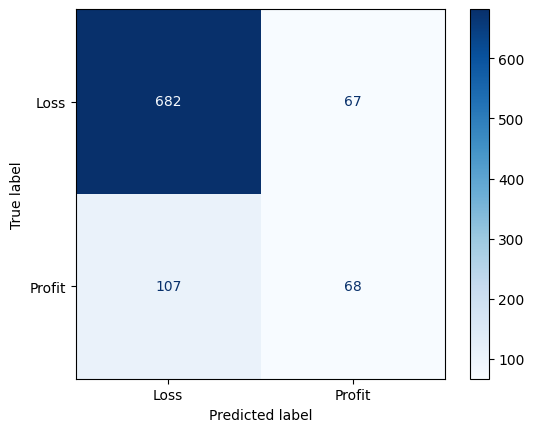

In [25]:
# Custom Threshold
# ==========================================
threshold = 0.40

# Probability of class 1 (Profit)
y_prob = lgr_best_model_v3.predict_proba(X_test)[:, 1]

# Apply custom threshold
y_pred = (y_prob >= threshold).astype(int)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    balanced_accuracy_score,
    roc_auc_score
)

print(f"Threshold: {threshold:.2f}\n")

print(classification_report(
    y_test,
    y_pred,
    target_names=["Loss (0)", "Profit (1)"]
))

print(f"Balanced Accuracy : {balanced_accuracy_score(y_test, y_pred):.4f}")
print(f"AUC-ROC           : {roc_auc_score(y_test, y_prob):.4f}")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Loss", "Profit"],
    cmap="Blues"
)

In [ ]:
# inspect the training performance as well as the test performance.

from sklearn.metrics import balanced_accuracy_score

train_pred = lgr_best_model_v3.predict(X_train)
test_pred = lgr_best_model_v3.predict(X_test)

print(
    "Train:",
    balanced_accuracy_score(y_train, train_pred)
)

print(
    "Test:",
    balanced_accuracy_score(y_test, test_pred)
)

In [ ]:
# Compare the Threshold
from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

y_prob = lgr_best_model_v3.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.10, 0.91, 0.05)

results = []

for t in thresholds:

    y_pred = (y_prob >= t).astype(int)

    results.append({
        "Threshold": t,
        "BalancedAccuracy": balanced_accuracy_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred)
    })

results = pd.DataFrame(results)

print(results)

In [48]:
# Make Classification Prediction from data file
import pandas as pd
from joblib import load

# ==========================================
# Load trained model
# ==========================================
model = load("LogisticRegression_V3.joblib")

# ==========================================
# Load Excel file
# ==========================================
new_df = pd.read_excel(r"C:\Users\Phong\OneDrive - ICB Construction\Phong\data\Python_ETL\DS\ML_Models\data\Quotation Data Test.xlsx")

# ==========================================
# Keep only raw features
# ==========================================
raw_features = [
    "Date",
    "Value",
    "No_Wall_Types",
    "Priced_By",
    "Contact_Clean",
    "Suburb",
    "Client_Clean",
    "Timber_RW","RC_Pile","Steel_Beam","Sheetpile","Anchor","Block",
    "Shotcrete","Capping_Beam","Earthwork","Concrete_Slab","Precast",
    "Culvert","Slip_Repair","Soil_Nail","Rock_RW","Bridge","Concrete",
    "Design_and_Build","Budget","Drill_Only","Labour_Only",
    "Driven_Pile","Palisade","Boardwalk","Soldier","Insitu",
    "Barrier","Noise_RW","Base","Casing","Crib",
    "DayWork","Flood_Repair","Micro_Pile","Reno",
    "Temp_RW","Other"
]

X_new = new_df[raw_features]

# ==========================================
# Predict
# ==========================================
pred_class = model.predict(X_new)

pred_probability = model.predict_proba(X_new)

# Probability of Profit (class=1)
won_probability = pred_probability[:,1]

lost_probability = pred_probability[:,0]

# ==========================================
# Save predictions
# ==========================================
new_df["Prediction"] = pred_class

new_df["Prediction_Label"] = new_df["Prediction"].map({
    0:"Lost",
    1:"Won"
})

new_df["Probability_Won"] = won_probability

new_df["Probability_Lost"] = lost_probability

# ==========================================
# Save Excel
# ==========================================
output_file = r"C:\Users\Phong\Downloads\Quotation Prediction Logistic.csv"

new_df.to_csv(
    output_file,
    index=False
)

print(f"Prediction saved to:\n{output_file}")

Prediction saved to:
C:\Users\Phong\Downloads\Quotation Prediction Logistic.csv


In [ ]:
# Inpect the distribution of grouper
client_counts = quotation_data_df["Client_Clean"].value_counts()

print(client_counts.describe())

print(client_counts.head(20))
print(client_counts.tail(20))


for threshold in [2, 5, 10, 20, 30, 50]:
    kept = (client_counts >= threshold).sum()
    print(f"{threshold:2d}: keep {kept:3d} clients")

In [ ]:
# Save dataframe after trasformation for checking
# 1. Build a preprocessing-only pipeline using your existing objects
debug_pipeline = Pipeline([
    ("date_features", DateFeatureTransformer()),
    ("estimator_features", EstimatorFeatureTransformer(
            column="Priced_By"
        )),
    ("numeric_features", NumericFeatureTransformer()),
    ("preprocessor", preprocessor)
])

# 2. Fit and transform your training data to see the final numeric matrix
X_train_transformed = debug_pipeline.fit_transform(X_train)

# 3. Retrieve the post-one-hot-encoded column names from the preprocessor step
# Note: This requires scikit-learn 1.0 or newer
feature_names = debug_pipeline.named_steps["preprocessor"].get_feature_names_out()

# 4. Reconstruct into a beautiful, readable DataFrame
transformed_df = pd.DataFrame(X_train_transformed, columns=feature_names, index=X_train.index)

# 5. Export locally to a CSV file
transformed_df.to_csv(r"C:\Users\Phong\Downloads\Quotation Data Test.csv", index=False)

print(f"✅ Success! Exported a matrix of {transformed_df.shape[0]} rows and {transformed_df.shape[1]} columns.")
print("Check your local directory for 'transformed_training_data.csv'.")

In [31]:
# Feature Importance (Logistic Regression Coefficients)
# ================================================================

# Get the fitted preprocessor
preprocessor = lgr_best_model_v3.named_steps["preprocessor"]

# Get transformed feature names
feature_names = preprocessor.get_feature_names_out()

# Get coefficients
coefficients = lgr_best_model_v3.named_steps["classifier"].coef_[0]

# Create DataFrame
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "AbsCoefficient": np.abs(coefficients)
})

# Sort by absolute importance
feature_importance = feature_importance.sort_values(
    by="AbsCoefficient",
    ascending=False
)

print("\nTop 30 Most Important Features")
print("=" * 80)
print(feature_importance.head(30))
print("=" * 80)


Top 30 Most Important Features
                                     Feature  Coefficient  AbsCoefficient
940                             bin__DayWork     3.434097        3.434097
644        cat__Client_Clean_naturalhabitats     2.761393        2.761393
114                    cat__Suburb_mahurangi     2.690235        2.690235
11                     cat__Priced_By_EGIDIO    -2.496911        2.496911
551                 cat__Client_Clean_ldeltd     2.492553        2.492553
261        cat__Client_Clean_aucklandcouncil     2.488039        2.488039
277               cat__Client_Clean_bobhicks     2.458525        2.458525
535             cat__Client_Clean_kerrydines     2.430377        2.430377
240           cat__Client_Clean_aintreegroup     2.429914        2.429914
338          cat__Client_Clean_civilsolution     2.420503        2.420503
241                cat__Client_Clean_airdale     2.417946        2.417946
369           cat__Client_Clean_cornwallpark     2.368124        2.368124
503   